In [9]:

# 📚 Import libraries
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [10]:

# 📥 Download NLTK stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# 🧹 Preprocessing function
def preprocess_text(text):
    if not isinstance(text, str):
        text = ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    words = text.split()
    return [word for word in words if word not in stop_words]

# 🏷️ Sentiment labeling function using TextBlob
def classify_sentiment(text):
    if not isinstance(text, str):
        text = ""
    score = TextBlob(text).sentiment.polarity
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:

# 📂 Load training dataset
train_df = pd.read_csv('train_dataset.csv')
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)

# 🏷️ Apply TextBlob for sentiment classification
train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)

# 💾 Save the new labeled dataset
train_df.to_csv('train_dataset_sentiment_textblob_only.csv', index=False)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'nb__alpha': 1.0, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Best Cross-Validation F1 Score: 0.7596674024224301
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.75      0.66       153
           1       0.93      0.78      0.85       832
           2       0.76      0.92      0.83       445

    accuracy                           0.82      1430
   macro avg       0.76      0.82      0.78      1430
weighted avg       0.84      0.82      0.83      1430



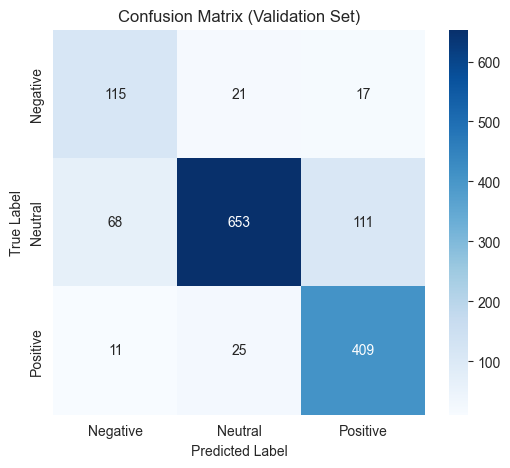

✅ Validation Accuracy: 82.31%
Model saved as sentiment_model.joblib


In [12]:

# 🧹 Prepare inputs for model training
X = train_df['Final_Comment']
y = train_df['Sentiment']  # TextBlob-labeled sentiments

# Map string labels to numeric for ML model
sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
y = y.map(sentiment_mapping)

# 🚂 Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 🏗️ Build a pipeline (TfidfVectorizer + ComplementNB)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', ComplementNB())
])

# 🔍 Define hyperparameter grid
param_grid = {
    'tfidf__max_df': [0.8, 1.0],
    'tfidf__min_df': [1, 5],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'nb__alpha': [0.1, 0.5, 1.0]
}

# 🔎 Perform GridSearchCV
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

# 🏆 Output best hyperparameters and F1-score
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation F1 Score:", grid.best_score_)

# 🧪 Evaluate on validation set
y_pred = grid.predict(X_val)

# 📊 Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred))

# 📊 Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 📈 Overall accuracy
print(f"✅ Validation Accuracy: {accuracy_score(y_val, y_pred) * 100:.2f}%")

# 📦 Save the trained model using joblib (single save method)
import joblib

# Save the best model (the one selected by GridSearchCV)
joblib.dump(grid.best_estimator_, 'sentiment_model.joblib')

print("Model saved as sentiment_model.joblib")


C:\Users\amirb\AppData\Local\Temp\ipykernel_7088\1881303574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=train_df, palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


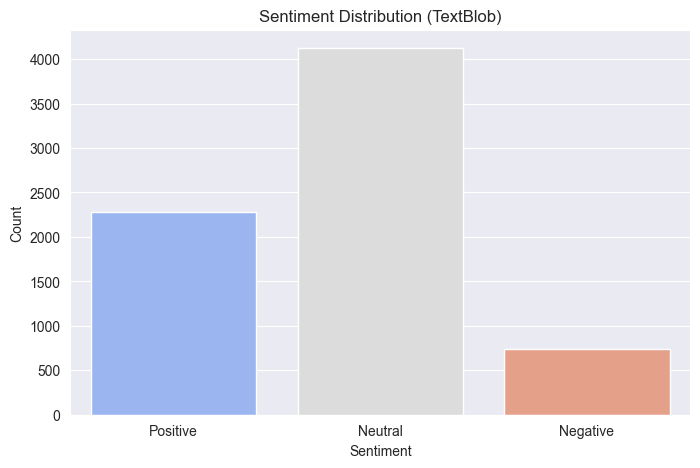

In [13]:

# 📊 Sentiment distribution visualization
plt.figure(figsize=(8,5))
sns.countplot(x='Sentiment', data=train_df, palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution (TextBlob)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


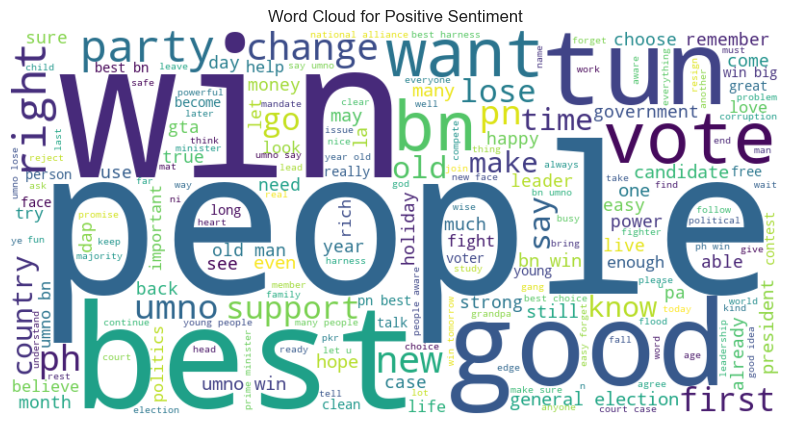

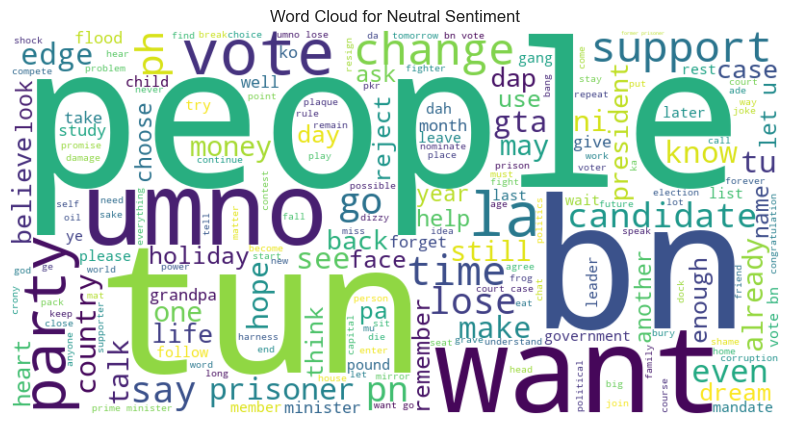

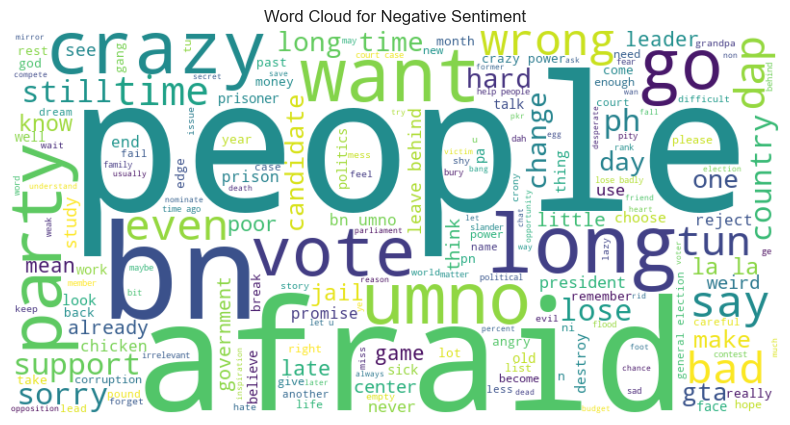

In [14]:

# ☁️ Generate word clouds for each sentiment
for sentiment in ['Positive', 'Neutral', 'Negative']:
    words = train_df[train_df['Sentiment'] == sentiment]['Final_Comment'].apply(preprocess_text).sum()
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {sentiment} Sentiment')
    plt.show()


In [15]:

# 🔹 Display Top 10 Common Words
all_words = train_df['Final_Comment'].apply(preprocess_text).sum()
print("🔹 Top 10 Common Words in Dataset:", Counter(all_words).most_common(10))


🔹 Top 10 Common Words in Dataset: [('people', 775), ('bn', 639), ('umno', 559), ('win', 483), ('vote', 447), ('tun', 439), ('want', 423), ('party', 355), ('best', 349), ('change', 334)]


In [16]:

# Load the saved model
model = joblib.load('sentiment_model.joblib')

# Use the model to make predictions
predictions = model.predict(X_val)
print("Predictions:", predictions)


Predictions: [1 1 2 ... 2 0 1]
